Name: Dhairya Kantawala

Roll Number: 23B3321

Email: dhairya@iitb.ac.in

# MDP policy itt code

In [299]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import os

class AgoOfInformation:
    def __init__(self, L, eta, sigma, q):
        self.L = L
        self.eta = eta
        self.sigma = sigma
        self.q = q

        def f(i, j):
            if i < self.L and j < self.L:
                return math.exp(-self.eta * i - j)
            else:
                return 0.0

        self.rewards = np.zeros((self.L+1, self.L+1, 3))
        for i in range(self.L+1):
            for j in range(self.L+1):
                self.rewards[i, j, 0] = f(i, j)
                self.rewards[i, j, 1] = f(i, j) - self.sigma
                self.rewards[i, j, 2] = f(i, j) - self.sigma

        self.transitions = np.zeros((self.L+1, self.L+1, self.L+1, self.L+1, 3))
        for i in range(self.L+1):
            for j in range(self.L+1):
                if i < self.L and j < self.L:
                    self.transitions[i+1, j+1, i, j, 0] = 1.0
                    self.transitions[i+1, j+1, i, j, 1] = 1.0 - self.q
                    self.transitions[i+1, j+1, i, j, 2] = 1.0 - self.q
                    self.transitions[i+1, 0, i, j, 2] = self.q
                    self.transitions[0, j+1, i, j, 1] = self.q

                if i == self.L and j < self.L:
                    self.transitions[i, j+1, i, j, 0] = 1.0
                    self.transitions[i, j+1, i, j, 1] = 1.0 - self.q
                    self.transitions[i, j+1, i, j, 2] = 1.0 - self.q
                    self.transitions[i, 0, i, j, 2] = self.q
                    self.transitions[0, j+1, i, j, 1] = self.q

                if j == self.L and i < self.L:
                    self.transitions[i+1, j, i, j, 0] = 1.0
                    self.transitions[i+1, j, i, j, 1] = 1.0 - self.q
                    self.transitions[i+1, j, i, j, 2] = 1.0 - self.q
                    self.transitions[i+1, 0, i, j, 2] = self.q
                    self.transitions[0, j, i, j, 1] = self.q

                if i == self.L and j == self.L:
                    self.transitions[i, j, i, j, 0] = 1.0
                    self.transitions[i, j, i, j, 1] = 1.0 - self.q
                    self.transitions[i, j, i, j, 2] = 1.0 - self.q
                    self.transitions[i, 0, i, j, 2] = self.q
                    self.transitions[0, j, i, j, 1] = self.q

    def optimal_policy_iteration(self, lam):
        S = (self.L+1)*(self.L+1)
        idx = lambda i,j: i*(self.L+1)+j

        d = np.zeros((self.L+1, self.L+1), dtype=int)

        while True:
            P = np.zeros((S, S))
            R = np.zeros(S)
            for i in range(self.L+1):
                for j in range(self.L+1):
                    s = idx(i,j)
                    a = d[i,j]
                    R[s] = self.rewards[i,j,a]
                    for ni in range(self.L+1):
                        for nj in range(self.L+1):
                            ns = idx(ni,nj)
                            P[s, ns] = self.transitions[ni,nj,i,j,a]

            V_flat = np.linalg.solve(np.eye(S) - lam*P, R)
            v = V_flat.reshape((self.L+1, self.L+1))

            d_new = np.zeros_like(d)
            for i in range(self.L+1):
                for j in range(self.L+1):
                    Q = np.zeros(3)
                    for a in range(3):
                        q_val = self.rewards[i,j,a]
                        for ni in range(self.L+1):
                            for nj in range(self.L+1):
                                q_val += lam*self.transitions[ni,nj,i,j,a]*v[ni,nj]
                        Q[a] = q_val
                    d_new[i,j] = np.argmax(Q)

            if np.array_equal(d, d_new):
                break
            d = d_new
        return d, v

    def policy_metrics(self, d):
        S = (self.L + 1) * (self.L + 1)
        idx = lambda i, j: i * (self.L + 1) + j

        P = np.zeros((S, S))
        R_vec = np.zeros(S)
        for i in range(self.L + 1):
            for j in range(self.L + 1):
                s = idx(i, j)
                a = int(d[i, j])
                R_vec[s] = self.rewards[i, j, a]
                for ni in range(self.L + 1):
                    for nj in range(self.L + 1):
                        ns = idx(ni, nj)
                        P[s, ns] = self.transitions[ni, nj, i, j, a]

        A = P.T - np.eye(S)
        A[-1, :] = 1.0
        b = np.zeros(S)
        b[-1] = 1.0
        try:
            pi = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            pi = np.ones(S) / S
            for _ in range(10000):
                pi_new = pi @ P
                if np.linalg.norm(pi_new - pi, 1) < 1e-12:
                    break
                pi = pi_new
            pi = pi / pi.sum()

        pi = pi.astype(float)
        pi /= pi.sum()

        Pstar = np.ones((S, 1)) @ pi.reshape(1, S)

        g = pi.dot(R_vec)

        I = np.eye(S)
        M = I - P + Pstar
        try:
            Z = np.linalg.inv(M)
        except np.linalg.LinAlgError:
            Z = np.linalg.solve(M, I)

        D = Z - Pstar
        ones = np.ones(S)
        h = D.dot(R_vec - g * ones)

        h -= ones * (pi.dot(h))
        h = h.reshape((S,))
        S = (self.L + 1)
        h_grid = h.reshape((S, S))
        return g, h_grid

    def B(self, g, h_grid):
        S = self.L + 1
        idx = lambda i, j: i * S + j
        h_flat = h_grid.reshape(S * S)

        B_grid = np.zeros((S, S))
        for i in range(S):
            for j in range(S):
                Q = np.zeros(3)
                for a in range(3):
                    val = 0.0
                    for ni in range(S):
                        for nj in range(S):
                            ns = idx(ni, nj)
                            val += self.transitions[ni, nj, i, j, a] * h_flat[ns]
                    Q[a] = self.rewards[i, j, a] - g + val - h_flat[idx(i, j)]
                B_grid[i, j] = np.max(Q)

        return B_grid

KeyboardInterrupt: 

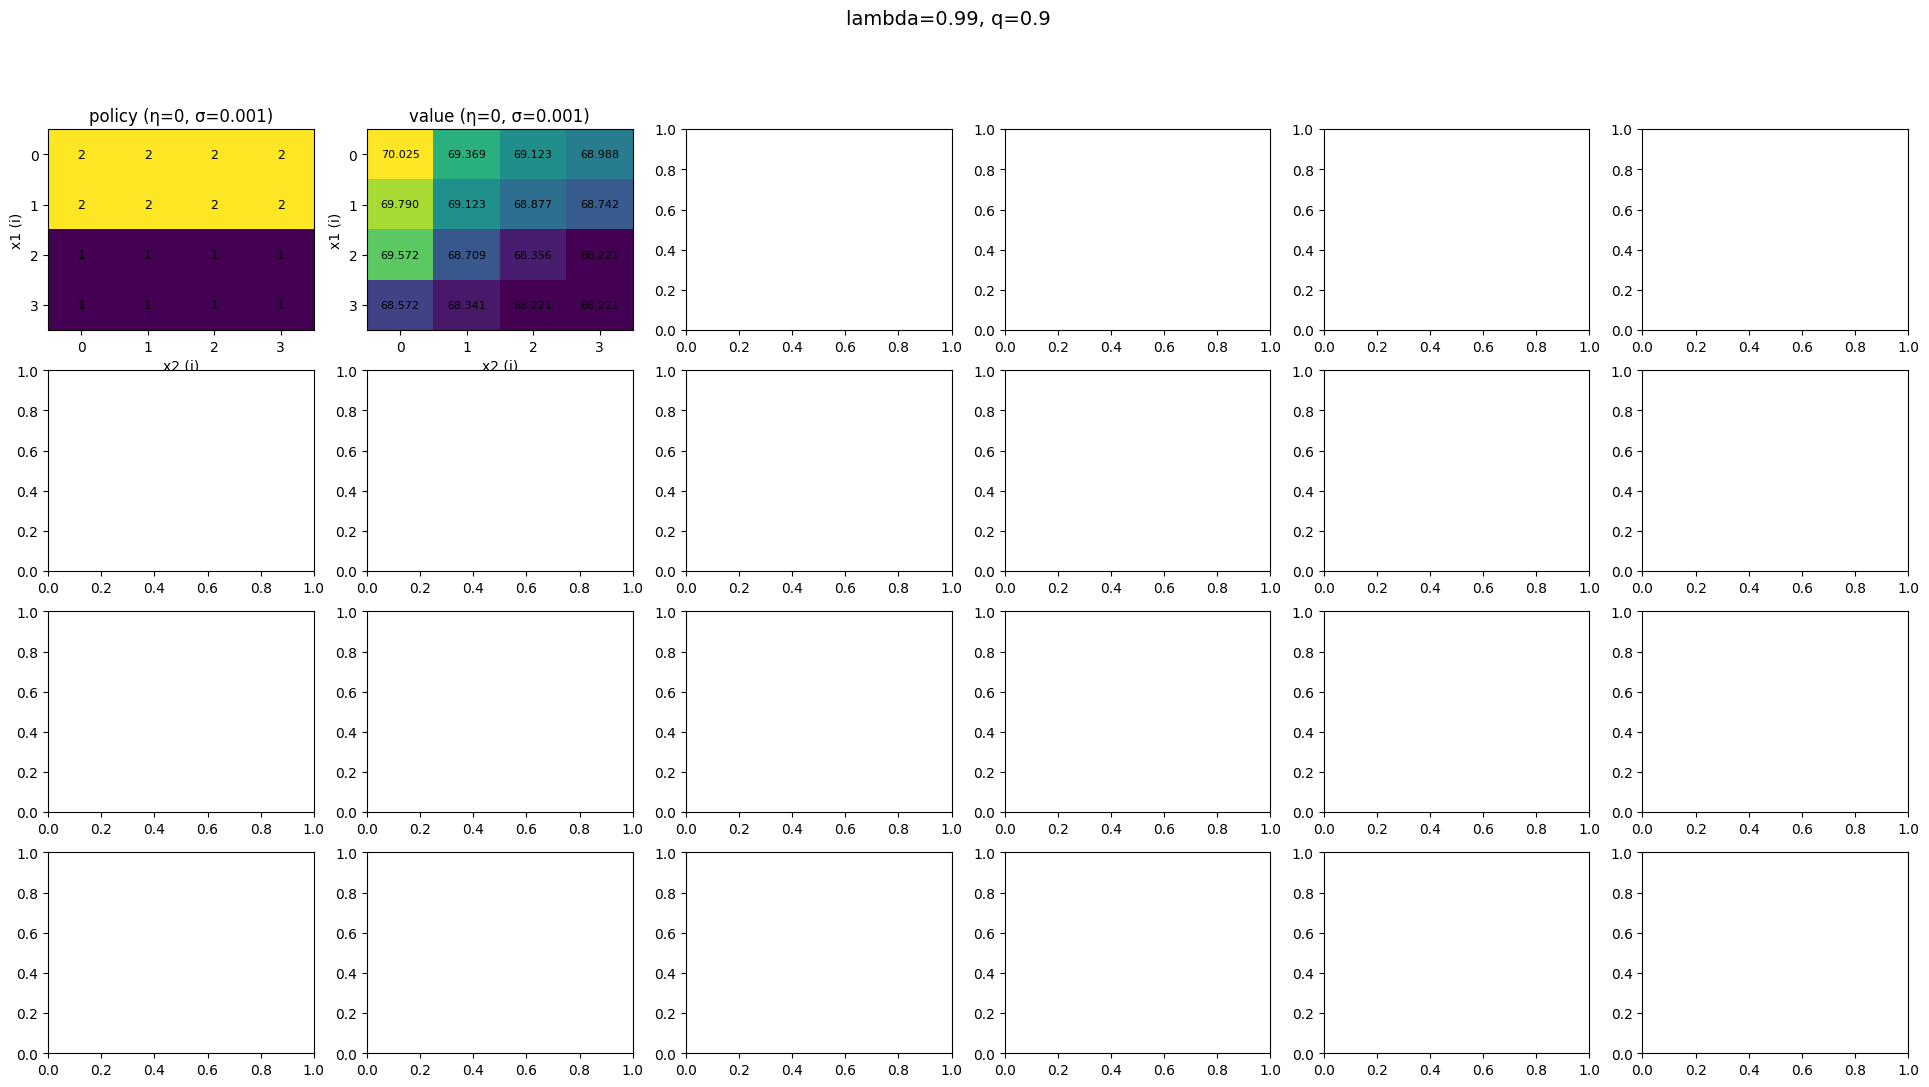

In [300]:
L = 3
etas = [0, 1, 2]
sigmas = [0.001, 0.01, 0.1, 1.0]
qs = [0.1, 0.5, 0.9]
lambdas = [0.9, 0.95, 0.99, 0.999]

out_dir = "./aoi_plots"
os.makedirs(out_dir, exist_ok=True)

saved_files = []

# Helper: build grid index map
def idx_flat(i, j, L):
    return i*(L+1) + j

# 1) For each q and lambda create a figure showing policy and value for every (eta, sigma) combo.
for q in qs:
    for lam in lambdas:
        fig, axes = plt.subplots(len(sigmas), len(etas)*2, figsize=(4*len(etas)*2, 3*len(sigmas)))
        fig.suptitle(f"lambda={lam}, q={q}", fontsize=14)
        for si, sigma in enumerate(sigmas):
            for ei, eta in enumerate(etas):
                # compute mdp
                mdp = AgoOfInformation(L, eta, sigma, q)
                d, v = mdp.optimal_policy_iteration(lam)
                # policy plot -> left column for this eta
                ax_policy = axes[si, ei*2]
                im1 = ax_policy.imshow(d, aspect='auto')
                ax_policy.set_title(f"policy (η={eta}, σ={sigma})")
                ax_policy.set_xlabel("x2 (j)")
                ax_policy.set_ylabel("x1 (i)")
                # annotate values
                for (i, j), val in np.ndenumerate(d):
                    ax_policy.text(j, i, str(int(val)), ha='center', va='center', fontsize=9)
                # value plot -> right column
                ax_value = axes[si, ei*2 + 1]
                im2 = ax_value.imshow(v, aspect='auto')
                ax_value.set_title(f"value (η={eta}, σ={sigma})")
                ax_value.set_xlabel("x2 (j)")
                ax_value.set_ylabel("x1 (i)")
                # annotate numeric values
                for (i, j), val in np.ndenumerate(v):
                    ax_value.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        fname = os.path.join(out_dir, f"policy_value_lambda_{str(lam).replace('.','p')}_q_{str(q).replace('.','p')}.png")
        fig.savefig(fname, dpi=200)
        plt.close(fig)
        saved_files.append(fname)

# 2) For lambda=0.999 compute g over (eta, sigma) grid for each q and plot heatmap
for q in qs:
    g_grid = np.zeros((len(sigmas), len(etas)))
    for si, sigma in enumerate(sigmas):
        for ei, eta in enumerate(etas):
            mdp = AgoOfInformation(L, eta, sigma, q)
            d, v = mdp.optimal_policy_iteration(0.999)
            g, h = mdp.policy_metrics(d)
            g_grid[si, ei] = g
    # plot heatmap for g
    fig, ax = plt.subplots(figsize=(6,4))
    im = ax.imshow(g_grid, aspect='auto')
    ax.set_xticks(np.arange(len(etas)))
    ax.set_yticks(np.arange(len(sigmas)))
    ax.set_xticklabels([str(e) for e in etas])
    ax.set_yticklabels([str(s) for s in sigmas])
    ax.set_xlabel("eta")
    ax.set_ylabel("sigma")
    ax.set_title(f"Gain g (lambda=0.999, q={q})")
    # annotate
    for (i,j), val in np.ndenumerate(g_grid):
        ax.text(j, i, f"{val:.4f}", ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax)
    fname = os.path.join(out_dir, f"gain_lambda_0p999_q_{str(q).replace('.','p')}.png")
    fig.savefig(fname, dpi=200)
    plt.close(fig)
    saved_files.append(fname)

# 3) For lambda=0.999, for every (eta, sigma, q) produce h and B(g,h) plots side-by-side
for q in qs:
    for si, sigma in enumerate(sigmas):
        for ei, eta in enumerate(etas):
            mdp = AgoOfInformation(L, eta, sigma, q)
            d, v = mdp.optimal_policy_iteration(0.999)
            g, h = mdp.policy_metrics(d)
            B = mdp.B(g, h)
            # create side-by-side figure: left=h, right=B
            fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,4))
            im1 = ax1.imshow(h, aspect='auto')
            ax1.set_title(f"h (eta={eta}, sigma={sigma}, q={q})")
            ax1.set_xlabel("x2")
            ax1.set_ylabel("x1")
            for (i,j), val in np.ndenumerate(h):
                ax1.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8)
            plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
            im2 = ax2.imshow(B, aspect='auto')
            ax2.set_title(f"B(g,h) (eta={eta}, sigma={sigma}, q={q})")
            ax2.set_xlabel("x2")
            ax2.set_ylabel("x1")
            for (i,j), val in np.ndenumerate(B):
                ax2.text(j, i, f"{val:.2e}", ha='center', va='center', fontsize=8)
            plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
            plt.suptitle(f"lambda=0.999, q={q}, eta={eta}, sigma={sigma}")
            plt.tight_layout(rect=[0,0.03,1,0.95])
            fname = os.path.join(out_dir, f"h_B_lambda_0p999_q_{str(q).replace('.','p')}_eta_{eta}_sigma_{str(sigma).replace('.','p')}.png")
            fig.savefig(fname, dpi=200)
            plt.close(fig)
            saved_files.append(fname)

# summary
print("Saved plot files:")
for f in saved_files:
    print(f)

len(saved_files), saved_files[:10]  # return some info


In [304]:
import os
import numpy as np
import matplotlib.pyplot as plt

L = 3
etas = [1, 2]
sigmas = [0.01]
qs = [0.8]
lambdas = [0.9, 0.95, 0.99, 0.999]

out_dir = "./aoi_report_plots"
os.makedirs(out_dir, exist_ok=True)
saved_files = []

def idx_flat(i, j, L):
    return i * (L + 1) + j

# main loop
for q in qs:
    for sigma in sigmas:
        for eta in etas:
            mdp = AgoOfInformation(L, eta, sigma, q)
            
            for lam in lambdas:
                # compute policy and value
                d, v = mdp.optimal_policy_iteration(lam)
                fig_rows, fig_cols = (1, 2)
                
                if lam == 0.999:
                    # compute g, h, B
                    g, h = mdp.policy_metrics(d)
                    B = mdp.B(g, h)
                    fig_rows, fig_cols = (2, 3)
                    fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(12, 7))
                else:
                    fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(8, 3.5))
                
                # handle axes flattening for easier indexing
                axes = np.atleast_2d(axes)
                ax_policy, ax_value = axes[0, 0], axes[0, 1]

                # Plot policy
                im1 = ax_policy.imshow(d, aspect='auto')
                ax_policy.set_title("Policy d")
                ax_policy.set_xlabel("x₂ (j)")
                ax_policy.set_ylabel("x₁ (i)")
                for (i, j), val in np.ndenumerate(d):
                    ax_policy.text(j, i, f"{int(val)}", ha='center', va='center', fontsize=9)
                plt.colorbar(im1, ax=ax_policy, fraction=0.046, pad=0.04)

                # Plot value
                im2 = ax_value.imshow(v, aspect='auto')
                ax_value.set_title("Value V")
                ax_value.set_xlabel("x₂ (j)")
                ax_value.set_ylabel("x₁ (i)")
                for (i, j), val in np.ndenumerate(v):
                    ax_value.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8)
                plt.colorbar(im2, ax=ax_value, fraction=0.046, pad=0.04)

                # if lambda=0.999, also show g, h, B
                if lam == 0.999:
                    # display g prominently
                    axes[0, 2].axis('off')
                    axes[0, 2].text(0.5, 0.5, f"g = {g:.6f}", ha='center', va='center', fontsize=14, fontweight='bold')
                    
                    # h plot
                    im3 = axes[1, 0].imshow(h, aspect='auto')
                    axes[1, 0].set_title("Bias h(i,j)")
                    axes[1, 0].set_xlabel("x₂ (j)")
                    axes[1, 0].set_ylabel("x₁ (i)")
                    for (i, j), val in np.ndenumerate(h):
                        axes[1, 0].text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8)
                    plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

                    # B plot
                    im4 = axes[1, 1].imshow(B, aspect='auto')
                    axes[1, 1].set_title("B(g, h)")
                    axes[1, 1].set_xlabel("x₂ (j)")
                    axes[1, 1].set_ylabel("x₁ (i)")
                    for (i, j), val in np.ndenumerate(B):
                        axes[1, 1].text(j, i, f"{val:.2e}", ha='center', va='center', fontsize=7)
                    plt.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

                    # blank out last cell for visual balance
                    axes[1, 2].axis('off')

                fig.suptitle(f"η={eta}, σ={sigma}, q={q}, λ={lam}", fontsize=13)
                plt.tight_layout(rect=[0, 0.03, 1, 0.95])

                fname = os.path.join(
                    out_dir,
                    f"eta_{eta}_sigma_{str(sigma).replace('.','p')}_q_{str(q).replace('.','p')}_lambda_{str(lam).replace('.','p')}.png"
                )
                fig.savefig(fname, dpi=200)
                plt.close(fig)
                saved_files.append(fname)

print(f"✅ Generated {len(saved_files)} figures.")
print("Sample:", saved_files[:6])


KeyboardInterrupt: 